# **Regulatory Affairs of Road Accident Data 2020 India**

## Tools Used  

- **Python**  
  Core programming language used for data analysis, preprocessing, and model building  

- **Pandas**  
  Used for data loading, cleaning, preprocessing, and handling structured accident datasets  

- **NumPy**  
  Used for numerical computations and array operations  

- **Matplotlib**  
  Used for basic data visualization such as plots and charts  

- **Seaborn**  
  Used for advanced statistical visualizations like correlation heatmaps and data distributions  

- **Scikit-learn**  
  Used for:  
  - Model building (Random Forest Regressor)  
  - Data preprocessing (LabelEncoder)  
  - Model evaluation (Mean Squared Error, R² Score)  
  - Data splitting (train_test_split)  

## Problem Definition  

This project focuses on analyzing road accident data across major Indian cities to identify the key causes and patterns of accidents. It examines factors such as traffic violations, road conditions, and environmental influences. The objective is to understand how these factors impact accident outcomes like injuries and fatalities. The insights can help in improving road safety and policy-making.

In [1]:
# Importing libraries used for data manipulation and visualization
import pandas as pd
import numpy as np

# Libraries for plotting graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set visual style for graphs
sns.set(style="whitegrid")

## Load Dataset  

The dataset contains road accident data for major cities in India, including details such as cause category, subcategory, accident outcomes, and incident counts. It is used to analyze accident patterns and understand the relationship between different causes and their impact on injuries, fatalities, and overall accident frequency.

In [2]:
# Load the dataset containing road accident data for Indian cities
df = pd.read_csv("/content/Regulatory Affairs of Road Accident Data 2020 India.csv")

# Display first few rows to understand the dataset
df.head()

,Million Plus Cities,Cause category,Cause Subcategory,Outcome of Incident,Count
0,Agra,Traffic Control,Flashing Signal/Blinker,Greviously Injured,0.0
1,Agra,Traffic Control,Flashing Signal/Blinker,Minor Injury,0.0
2,Agra,Traffic Control,Flashing Signal/Blinker,Persons Killed,0.0
3,Agra,Traffic Control,Flashing Signal/Blinker,Total Injured,0.0
4,Agra,Traffic Control,Flashing Signal/Blinker,Total number of Accidents,0.0



## Dataset Overview & Missing Values Explanation  

- The dataset contains **9550 rows and 5 columns**, representing road accident data across major cities in India.  
- Most columns are **categorical (object type)**, while **"Count" is numerical (float)** representing the number of incidents.  

### Data Quality  
- All columns have complete data **except "Count"**, which has **3 missing values**.  
- This is confirmed using `df.isnull().sum()`, where only the "Count" column shows missing entries.  

### Statistical Summary  
- The **average accident count** is around **103**, with values ranging from **0 to 3148**, indicating high variation in accident frequency.  

### Handling Missing Values  
- Missing values in the "Count" column are replaced with **0 using `fillna(0)`**, assuming no recorded accidents for those entries.  
- After this step, the dataset becomes **complete with no missing values**, making it ready for analysis and modeling.

In [3]:
# Display number of rows and columns
df.shape

# Display data types and non-null values
df.info()

# Display statistical summary of numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9550 entries, 0 to 9549
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Million Plus Cities  9550 non-null   object 
 1   Cause category       9550 non-null   object 
 2   Cause Subcategory    9550 non-null   object 
 3   Outcome of Incident  9550 non-null   object 
 4   Count                9547 non-null   float64
dtypes: float64(1), object(4)
memory usage: 373.2+ KB


,Count
count,9547.000000
mean,103.627632
std,275.189303
min,0.000000
25%,0.000000
50%,12.000000
75%,70.500000
max,3148.000000


In [4]:
# Checking if any values are missing in the dataset
df.isnull().sum()

,0
Million Plus Cities,0
Cause category,0
Cause Subcategory,0
Outcome of Incident,0
Count,3


In [6]:
# Replace missing accident counts with 0
df['Count'] = df['Count'].fillna(0)

# **Exploratory Data Analysis (EDA)**

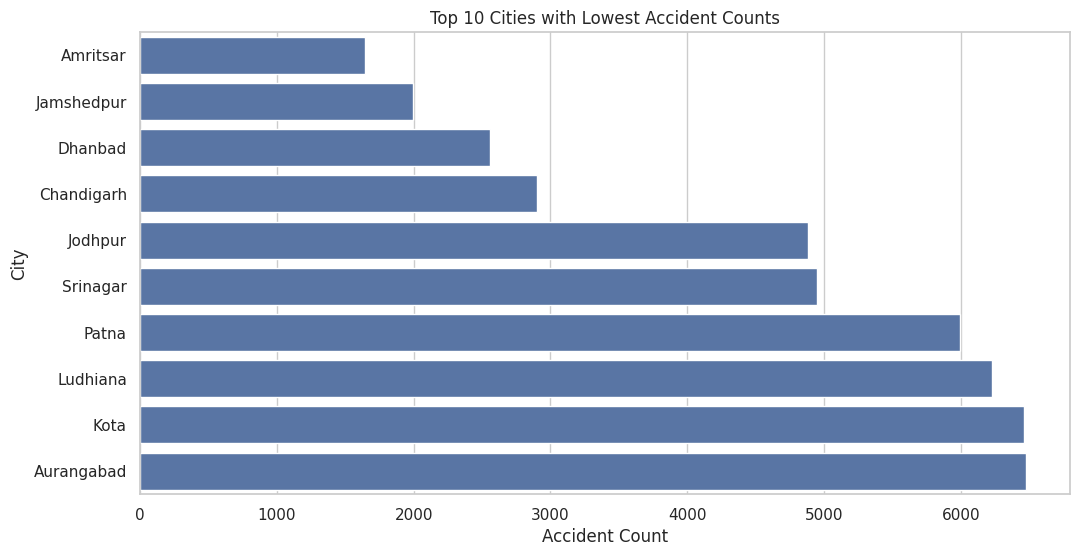

In [10]:
city_accidents = df.groupby('Million Plus Cities')['Count'].sum()

lowest_cities = city_accidents.sort_values().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=lowest_cities.values,
    y=lowest_cities.index
)

plt.title("Top 10 Cities with Lowest Accident Counts")
plt.xlabel("Accident Count")
plt.ylabel("City")

plt.show()

# Cities with Lowest Accident Counts

## What this chart shows

This bar chart displays the ten cities reporting the lowest number of road accidents in the dataset.

## Key observations

- Some cities consistently record significantly fewer accidents than others.
- Lower accident counts may indicate better road infrastructure or safer driving practices.
- Population size and traffic volume may also influence accident frequency.

## Business insight

Studying low-accident cities can help identify successful safety measures that can be replicated elsewhere.

## Actionable recommendation

- Analyze safety policies implemented in low-accident cities.
- Promote best practices across higher-risk cities.
- Conduct comparative studies to identify success factors.

## Key takeaway

Cities with fewer accidents may provide valuable insights for improving road safety across the country.

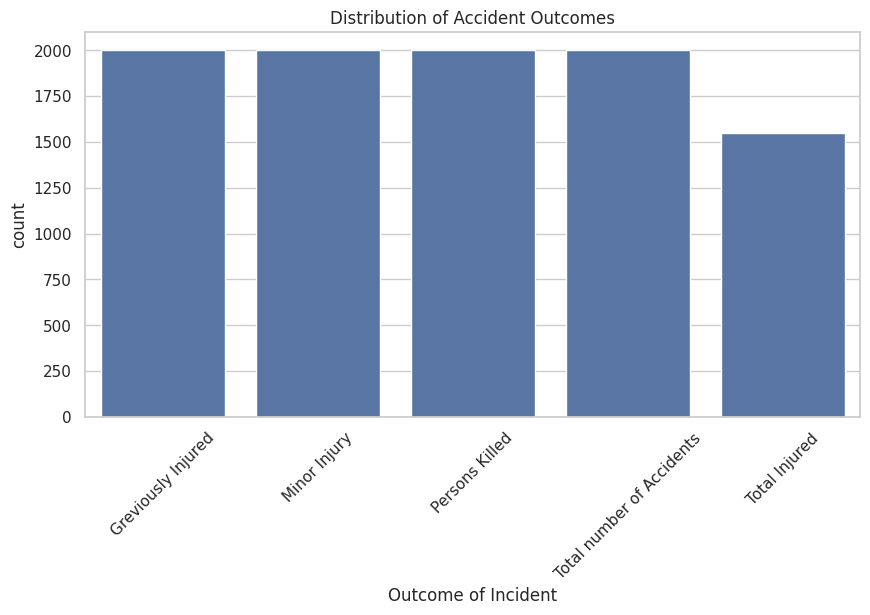

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Outcome of Incident',
    order=df['Outcome of Incident'].value_counts().index
)

plt.title("Distribution of Accident Outcomes")
plt.xticks(rotation=45)

plt.show()

# Distribution of Accident Outcomes

## What this chart shows

This chart displays the frequency of different accident outcomes recorded in the dataset.

## Key observations

- Certain outcomes occur much more frequently than others.
- Fatal and severe outcomes may represent a smaller proportion but have greater impact.
- The distribution provides insight into the severity profile of road accidents.

## Business insight

Understanding accident outcomes helps authorities prioritize emergency response planning and safety initiatives.

## Actionable recommendation

- Focus on reducing severe and fatal outcomes.
- Improve emergency medical response systems.
- Strengthen enforcement of road safety regulations.

## Key takeaway

Accident outcomes vary significantly, highlighting the importance of targeted safety interventions.

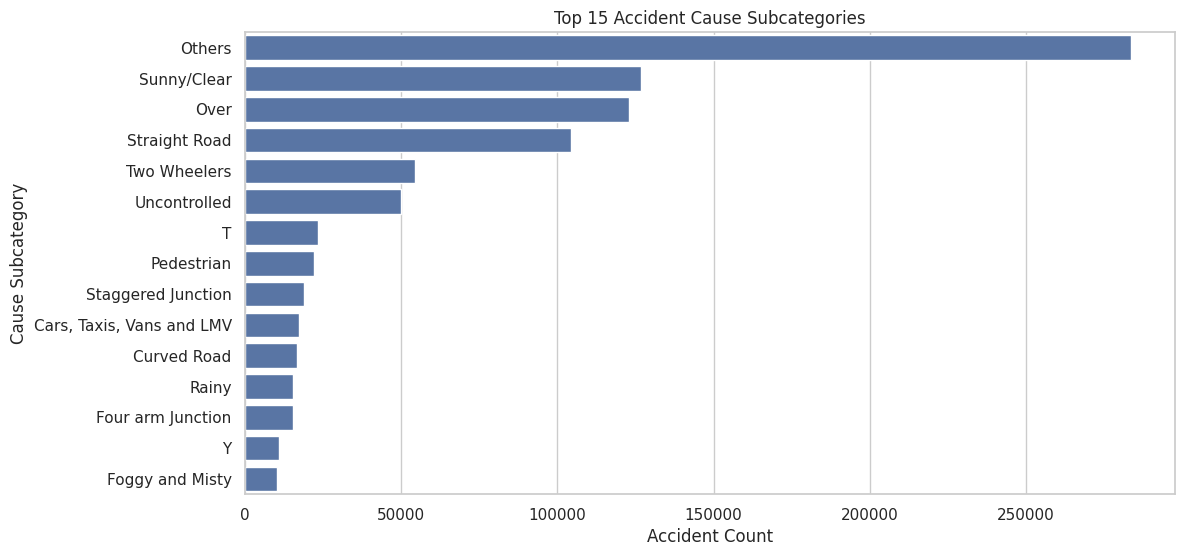

In [12]:
top_sub = df.groupby('Cause Subcategory')['Count'].sum()

top_sub = top_sub.sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_sub.values,
    y=top_sub.index
)

plt.title("Top 15 Accident Cause Subcategories")
plt.xlabel("Accident Count")

plt.show()

# Top Accident Cause Subcategories

## What this chart shows

This chart identifies the most common specific causes contributing to road accidents.

## Key observations

- A small number of subcategories account for a large share of accidents.
- Certain driver behaviors and road conditions contribute disproportionately to accident occurrence.
- The chart highlights critical areas requiring intervention.

## Business insight

Identifying specific accident causes enables more focused road safety policies and awareness campaigns.

## Actionable recommendation

- Develop targeted awareness programs addressing major accident causes.
- Increase enforcement against risky driving behaviors.
- Improve road infrastructure where relevant.

## Key takeaway

A limited number of specific causes contribute heavily to accident rates, making targeted prevention strategies highly effective.

# **ML MODEL**


In [ ]:
# Machine learning models require numerical data
# Convert categorical columns into numeric labels

le = LabelEncoder()

df_ml = df.copy()

df_ml['City'] = le.fit_transform(df_ml['Million Plus Cities'])
df_ml['CauseCategory'] = le.fit_transform(df_ml['Cause category'])
df_ml['CauseSub'] = le.fit_transform(df_ml['Cause Subcategory'])
df_ml['Outcome'] = le.fit_transform(df_ml['Outcome of Incident'])

In [ ]:
# Independent variables (features)
X = df_ml[['City','CauseCategory','CauseSub','Outcome']]

# Dependent variable (target)
y = df_ml['Count']

In [ ]:
# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Create Random Forest regression model
model = RandomForestRegressor(n_estimators=200)

# Train the model using training data
model.fit(X_train, y_train)

# Predict accident counts for test data
pred = model.predict(X_test)

In [ ]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, pred)

# Calculate R-squared score
r2 = r2_score(y_test, pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 21234.434497200586
R2 Score: 0.6934986717360876


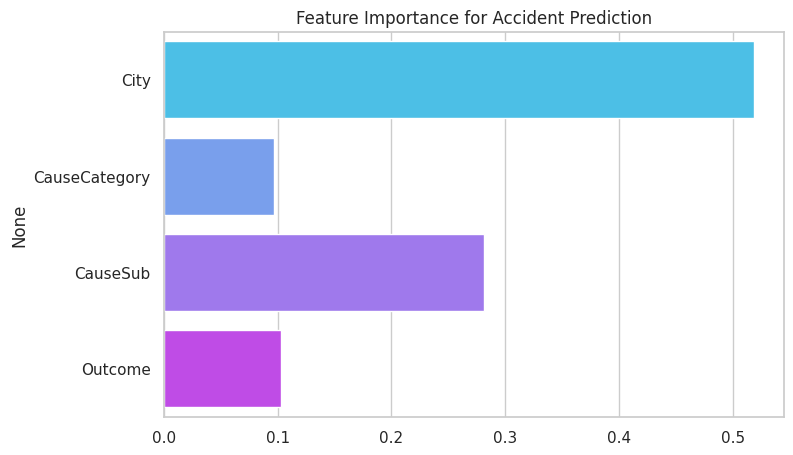

In [ ]:
# Train model (example using Random Forest)
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, y)

# Get feature importance
importance = model.feature_importances_
features = X.columns

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x=importance,
    y=features,
    hue=features,
    palette="cool",
    legend=False
)

plt.title("Feature Importance for Accident Prediction")

plt.show()

This graph shows the significance of various features used in the model for the machine learning prediction of the accident count.
From the above chart, we can infer that the City feature has the highest importance, which implies that the City where the accident occurred is a major factor for the accident count.
The subcategory of the cause of the accident is the second most important feature, which implies that the accident count is affected by the cause of the accident.
On the other hand, the cause category of the accident and the accident outcome have less importance for the prediction.

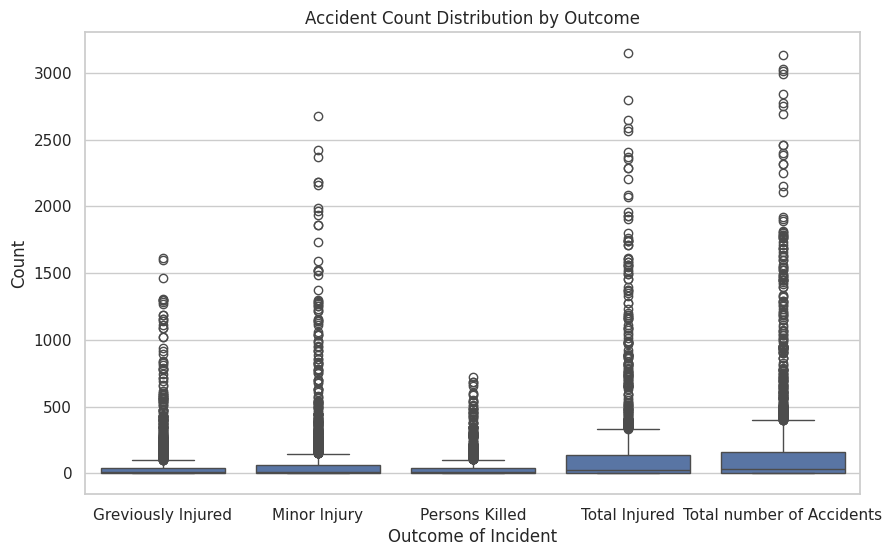

In [ ]:
# Box plot to observe accident count distribution for each outcome
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Outcome of Incident',
    y='Count',
    data=df
)

plt.title("Accident Count Distribution by Outcome")

plt.show()

This box plot illustrates the number of accidents in various cases such as grievous injuries, minor injuries, deaths, total injuries, and total accidents. The box illustrates the spread of the data, while the points represent the cases of outliers where the number of accidents is high.
From the box plot, it is clear that total injuries and total number of accidents are high, showing that these cases are more common. On the other hand, persons killed are low, showing that fatalities are less common in road accidents.

## Conclusion  

This project analyzed road accident data from major cities in India to identify patterns, causes, and outcomes of accidents in 2020. The analysis revealed that cities like Chennai and Delhi have the highest number of accidents, likely due to high population density, heavy traffic, and a large number of vehicles.  

The study showed that road accidents are influenced by multiple factors such as traffic violations, road features, weather conditions, junction design, and traffic control systems. This indicates that accidents are caused by a combination of human behavior and environmental conditions.  

It was also observed that most accidents result in injuries rather than fatalities, with minor and total injuries being more common. The Random Forest model further highlighted that city location and cause subcategory are key factors affecting accident frequency.  

Overall, this project demonstrates how data analysis and machine learning can uncover important accident trends and risk factors. These insights can help policymakers and authorities improve road safety measures, enhance infrastructure, and promote safer driving practices.